# Tree and Dictionary: Input + Lab

**Outline for today:**
- Understand Python *dictionaries* and the **key-value** idea  
- Build intuition for *hashing*  
- Learn what a *heap* is and how it works in Python  
- See a quick Data Science example of tree based models
- ⭐ Bonuses: "tuples" and `assert`

**Note:** In MC1, you will implement a Priority Queue yourself.  
In this notebook we will use `heapq` only to learn the heap concept and the core operations.

## 1) Dictionary

A dictionary maps **keys** to **values** `{K: V}`.

- Keys are unique, you cannot have the same key twice.
- Lookup by key is fast.
- Keys must be hashable (immutable).

**Immutable vs Mutable:**
- **Immutable** = cannot be modified. Examples: `int`, `str`, `tuple`. You can reassign the variable to a new value, but you can't change the object itself.
  - `var = "hello"` then `var = "world"` ✓ works (reassigning)
  - `var = "hello"` then `var[0] = "H"` ✗ fails (can't modify string)
- **Mutable** = can be modified. Examples: `list`, `set`, `dict`. You can change the object's contents.
  - `lst = [1, 2, 3]` then `lst[0] = 99` ✓ works (modifying list)

In [8]:
# Basic dictionary operations

scores = {"Alice": 5, "Bob": 3}  # dictionary initialization
print("scores:", scores)

# Insert or update
scores["Charlie"] = 4
scores["Bob"] = 6  # Bob's score updated
print("after insert and update:", scores)

# Read
print("Alice:", scores["Alice"])

# Safe read with default
print(
    "Dana:", scores.get("Dana", 0)
)  # Dana is not in the dictionary, so default 0 is returned

# Membership test
print("Bob in scores?", "Bob" in scores)

# Delete
del scores["Charlie"]
print("after delete:", scores)

scores: {'Alice': 5, 'Bob': 3}
after insert and update: {'Alice': 5, 'Bob': 6, 'Charlie': 4}
Alice: 5
Dana: 0
Bob in scores? True
after delete: {'Alice': 5, 'Bob': 6}


### Common patterns

#### Pattern A, counting
You will do this often in Data Science, for example counting words, labels, events.

In [4]:
# Pattern A: counting words

text = "to be or not to be"
words = text.split()
print("words:", words)

counts = {}  # empty dictionary to hold word counts
for current_word in words:
    counts[current_word] = counts.get(current_word, 0) + 1

print("word counts:", counts)

words: ['to', 'be', 'or', 'not', 'to', 'be']
word counts: {'to': 2, 'be': 2, 'or': 1, 'not': 1}


#### Pattern B, grouping
You will also group items by some key, for example group points by class label.

In [5]:
# Pattern B: grouping values by a key

# below "data" is a list of tuples with 2 elements: a label (string) and a value (float)
data = [("cat", 1.2), ("dog", 0.7), ("cat", 1.8), ("bird", 0.2), ("dog", 1.0)]

groups = {}
for label, value in data:
    groups.setdefault(label, []).append(value)

groups

{'cat': [1.2, 1.8], 'dog': [0.7, 1.0], 'bird': [0.2]}

##### ⭐ **Bonus:** Tuples

In [2]:
# Tuple examples
# You can use any hashable types in tuples
pair = ("Alice", 95)
triple = ("Bob", 87, "Math")
quad = (1, 2, 3, 4)
single = ("Charlie",)  # a single element tuple (note the comma!)
empty = ()  # an empty tuple
print("triple[1]:", triple[1])  # access second element of the triple
print("single:", single)

# Tuples as dictionary keys (because they're immutable/hashable)
location_data = {(0, 0): "origin", (1, 2): "point A", (1, 4): "point B"}
print("Location data:", location_data[(1, 2)])

# To get all entries with first coordinate = 1, you need to iterate and filter
matching = {k: v for k, v in location_data.items() if k[0] == 1}
print("All locations with x=1:", matching)

triple[1]: 87
single: ('Charlie',)
Location data: point A
All locations with x=1: {(1, 2): 'point A', (1, 4): 'point B'}


In [3]:
triple[1] = 88  # this will raise an error because tuples are immutable

TypeError: 'tuple' object does not support item assignment

### 1.1) Hashing intuition

Python dictionaries are based on hashing.

- A **hash function** maps a key to an integer.
- Internally, the dictionary uses this integer to find where the value should live (like an index in an array).
- **Collisions can happen** because there are infinitely many possible keys but only a finite number of storage slots.
  - Different keys might hash to the same slot (e.g., `hash("Alice") % 10` and `hash("Bob") % 10` might both be 3).
  - When this happens, Python uses techniques like chaining or probing to handle it.
- In practice, lookup and insert are usually close to constant time on average.

You do not need to know the internal layout for this course, but the intuition explains **why dictionaries are fast**.

In [13]:
# hash() gives an integer for a hashable object

print("hash('Alice'):", hash("Alice"))
print("hash('Bob'):", hash("Bob"))
print("hash(42):", hash(42))  # integers always hash to themselves
print("hash((1, 2, 3)):", hash((1, 2, 3)))

# Note: Since Python 3.3, hash values for strings and tuples change between runs for security reasons.
# But integers always hash to themselves (this is implementation-specific).

hash('Alice'): -2866396243951831725
hash('Bob'): -8916749327601046985
hash(42): 42
hash((1, 2, 3)): 529344067295497451


#### ⭐ **Bonus:** `assert` statements

When you write small helper functions, you can test them quickly with `assert`.
If an assertion fails, Python raises an error and tells you where it failed.

You can reuse this idea in assignments.

In [14]:
assert hash(42) == 42  # same integer should have same hash
assert hash((1, 2, 3)) == hash(
    (1, 2, 3)
)  # same tuple should have same hash within the same run

assert hash((1, 2, 3)) != hash(
    (1, 2, 4)
), "Error: Different tuples have different hashes!"

assert hash(42) == hash(52)

AssertionError: 

## 2) Tree

A tree is a data structure with nodes and parent child relationships.
``` yaml
           O root
        /  |  \
parent O   O   O leaf
      / \  | 
     O   O O child   
```
Trees are generalizations of linked lists where each node can have multiple children instead of just one. They are acyclic graphs (no cycles by definition).

**Trees in Computer Science:** Self-balancing trees like Red-Black trees, AVL trees, and B-trees maintain balance to ensure fast lookup/insert operations, while search trees like C4.5 and decision trees in ML are used for classification and prediction tasks.

**Key difference:** In CS, trees are primarily data structures for efficient searching/sorting; in Data Science, trees (Decision Trees, Random Forests, Gradient Boosted Trees) are predictive models that learn patterns from data for classification and regression.

In this course, we focus on **heaps** because you will use them in algorithms and in the game project.

**Tree vs Binary Tree:**

| Feature | General Tree | Binary Tree |
|---------|-------------|-------------|
| **Children per node** | Any number (0, 1, 2, 3, ...) | At most 2 (left and right) |
| **Structure** | More flexible | More constrained |
| **Example** | File system, organizational chart | Binary search tree, heap |
| **Use case** | Hierarchies with variable branching | Efficient searching, sorting |

### 2.1) Heaps in Python

A heap is a binary tree like structure with a simple rule.

For a **min heap**, the smallest element is always at the top: 
key(child) > key(parent).
Python provides `heapq` which implements a min heap on top of a normal list.
``` toml
         1
       /   \
      2     3
     / \   / 
    4   5 9   
```

Core operations:
- `heappush`, insert an item
- `heappop`, remove and return the smallest item
- `heap[0]`, peek at the smallest item
- `heapify`, turn a list into a heap

How this relates to a Priority Queue:
- A Priority Queue is an abstract data structure, it supports push and pop by priority.
- A heap is a common way to implement a Priority Queue efficiently.
- So, heaps are not only for Priority Queues, but Priority Queues are often built using heaps.

In [15]:
import heapq

heap = []

# Insert items
for x in [5, 1, 7, 3, 2]:
    heapq.heappush(heap, x)
    print("push", x, "->", heap)

print("peek smallest:", heap[0])

# Pop items in increasing order
while heap:
    smallest = heapq.heappop(heap)
    print("pop", smallest, "->", heap)

push 5 -> [5]
push 1 -> [1, 5]
push 7 -> [1, 5, 7]
push 3 -> [1, 3, 7, 5]
push 2 -> [1, 2, 7, 5, 3]
peek smallest: 1
pop 1 -> [2, 3, 7, 5]
pop 2 -> [3, 5, 7]
pop 3 -> [5, 7]
pop 5 -> [7]
pop 7 -> []


In [16]:
# heapify example, build a heap from an existing list

nums = [9, 4, 6, 1, 8, 2]
heapq.heapify(nums)
print("heapified:", nums)
print("peek:", nums[0])
print("pop:", heapq.heappop(nums))
print("after pop:", nums)

heapified: [1, 4, 2, 9, 8, 6]
peek: 1
pop: 1
after pop: [2, 4, 6, 9, 8]


### 2.2) Data Science example: Decision Tree in *scikit-learn*

This is a short demonstration. We train a small model and measure accuracy via a toy dataset, [iris](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-plants-dataset).

If `scikit-learn` is not installed in your environment, below cell will print a helpful message.

#### Loading the Dataset

In [17]:
try:
    from sklearn.datasets import load_iris
    import random

    iris = load_iris()
    X = iris.data
    y = iris.target
    print("Dataset loaded. Number of samples:", len(X))

    # display 5 random samples of the dataset
    print("Random 5 samples:")
    sample_indices = random.sample(range(len(X)), 5)
    for idx in sample_indices:
        print(f"X[{idx}] = {X[idx]}, y = {y[idx]} ({iris.target_names[y[idx]]})")

except ImportError as e:
    print("scikit learn is not installed in this environment.")
    print("If you want to run this demo, install it with: pip install scikit-learn")
    print("ImportError:", e)

Dataset loaded. Number of samples: 150
Random 5 samples:
X[49] = [5.  3.3 1.4 0.2], y = 0 (setosa)
X[130] = [7.4 2.8 6.1 1.9], y = 2 (virginica)
X[107] = [7.3 2.9 6.3 1.8], y = 2 (virginica)
X[19] = [5.1 3.8 1.5 0.3], y = 0 (setosa)
X[95] = [5.7 3.  4.2 1.2], y = 1 (versicolor)


#### Scatter Plot of the Iris dataset

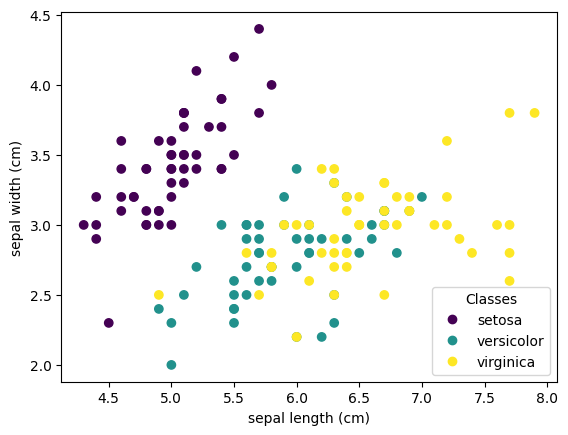

In [18]:
# This example is from scikit-learn documentation: https://scikit-learn.org/1.4/auto_examples/datasets/plot_iris_dataset.html
try:
    import matplotlib.pyplot as plt

    _, ax = plt.subplots()
    scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target)
    ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
    _ = ax.legend(
        scatter.legend_elements()[0],
        iris.target_names,
        loc="lower right",
        title="Classes",
    )
except ImportError as e:
    print("matplotlib is not installed in this environment.")
    print("If you want to run this demo, install it with: pip install matplotlib")
    print("ImportError:", e)

#### Training and Evaluation

In [19]:
try:
    import time
    from sklearn.model_selection import train_test_split
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.metrics import accuracy_score, classification_report

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=0, stratify=y
    )

    model = DecisionTreeClassifier(random_state=0, max_depth=3)
    print("Training started...")
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    training_time = end_time - start_time
    print(f"Training completed in {training_time:.4f} seconds.\n")

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    print(f"Accuracy: {acc:.2f}\n")
    print(classification_report(y_test, preds, target_names=iris.target_names))

except ImportError as e:
    print("scikit learn is not installed in this environment.")
    print("If you want to run this demo, install it with: pip install scikit-learn")
    print("ImportError:", e)

Training started...
Training completed in 0.0017 seconds.

Accuracy: 0.95

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.87      1.00      0.93        13
   virginica       1.00      0.83      0.91        12

    accuracy                           0.95        38
   macro avg       0.96      0.94      0.95        38
weighted avg       0.95      0.95      0.95        38



## 3) Wrap up

Take-home lessons:
- *Dictionaries* map keys to values, they are fast for membership and lookup on average.
- *Hashing* is the core idea behind dictionary speed.
- A *heap* keeps the smallest element at the top in a min-heap.
- *Priority Queues* are often implemented using heaps, but you can study heaps without building the full *Priority Queue* class.